# PE-U4 — Ejecucion del experimento en Google Colab

Las celdas se ejecutan secuencialmente.
Requiere cargar el paquete de código en la celda 2..

## Celda 1 — Verificación del entorno de ejecución

Colab asigna maquinas distintas. Necesitamos saber cuantos nucleos tiene,
porque de eso depende el experimento de Amdahl.

In [ ]:
import multiprocessing
nucleos = multiprocessing.cpu_count()
print("Nucleos disponibles:", nucleos)
print("Version de Java:")
!java -version
print()
if nucleos < 4:
    print("=" * 70)
    print("AVISO: esta maquina solo tiene " + str(nucleos) + " nucleos.")
    print("El barrido de 1/2/4 executors no mostrara ganancia real en N=4,")
    print("porque no hay 4 nucleos fisicos donde repartir el trabajo.")
    print()
    print("Opciones:")
    print("  a) Continuar igual y DOCUMENTARLO como limitacion experimental")
    print("     (es una respuesta valida y honesta para el informe).")
    print("  b) Entorno de ejecucion > Cambiar tipo de entorno > probar otra opcion,")
    print("     o usar Databricks Community Edition, que da mas nucleos.")
    print("=" * 70)
else:
    print("Perfecto: hay nucleos suficientes para el barrido de 1/2/4 executors.")

Nucleos disponibles: 2
Version de Java:
openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)

AVISO: esta maquina solo tiene 2 nucleos.
El barrido de 1/2/4 executors no mostrara ganancia real en N=4,
porque no hay 4 nucleos fisicos donde repartir el trabajo.

Opciones:
  a) Continuar igual y DOCUMENTARLO como limitacion experimental
     (es una respuesta valida y honesta para el informe).
  b) Entorno de ejecucion > Cambiar tipo de entorno > probar otra opcion,
     o usar Databricks Community Edition, que da mas nucleos.


## Celda 2 — Carga del proyecto

Al ejecutar esta celda aparece un boton **"Elegir archivos"**.
Se carga el paquete de código del experimento.

> **Nota tecnica.** `Compress-Archive` de Windows guarda las rutas internas con
> barra invertida (`core\\config.py`). En Linux eso no crea carpetas, sino archivos
> con ese nombre literal. Esta celda normaliza los separadores al descomprimir,
> asi que el ZIP de Windows funciona sin cambios.

In [ ]:
import os, shutil, zipfile
from google.colab import files

DESTINO = "/content/proyecto"
if os.path.exists(DESTINO):
    shutil.rmtree(DESTINO)
os.makedirs(DESTINO)

subidos = files.upload()
nombre_zip = list(subidos.keys())[0]

# Descomprimir normalizando los separadores de Windows (\\ -> /)
with zipfile.ZipFile(nombre_zip, "r") as z:
    for entrada in z.namelist():
        destino_rel = entrada.replace("\\", "/")
        if destino_rel.endswith("/"):
            continue
        destino_abs = os.path.join(DESTINO, destino_rel)
        os.makedirs(os.path.dirname(destino_abs), exist_ok=True)
        with z.open(entrada) as origen, open(destino_abs, "wb") as salida:
            shutil.copyfileobj(origen, salida)

# Buscar la carpeta que contiene core/ y main.py
RAIZ = None
for raiz, dirs, archivos in os.walk(DESTINO):
    dirs[:] = [d for d in dirs if d not in ("__pycache__", ".git", ".venv")]
    if "core" in dirs and "main.py" in archivos:
        RAIZ = raiz
        break

if RAIZ is None:
    print("NO se encontro el proyecto. Esto es lo que se descomprimio:")
    for raiz, dirs, archivos in os.walk(DESTINO):
        print(" ", raiz, "->", dirs, archivos[:8])
else:
    print("Proyecto encontrado en:", RAIZ)
    print()
    modulos = sorted(a for a in os.listdir(os.path.join(RAIZ, "core"))
                     if a.endswith(".py"))
    print("Modulos en core/ (" + str(len(modulos)) + "):")
    for m in modulos:
        print("   ", m)

Saving pe-u4-spark-equipo-b-main.zip to pe-u4-spark-equipo-b-main.zip
Proyecto encontrado en: /content/proyecto/pe-u4-spark-equipo-b-main

Modulos en core/ (9):
    __init__.py
    amdahl.py
    benchmark.py
    config.py
    dataset.py
    exportar_latex.py
    figuras.py
    transformaciones_pandas.py
    transformaciones_spark.py


## Celda 3 — Instalar PySpark

Tarda uno o dos minutos.

Es normal que aparezca un **ERROR rojo** sobre `dataproc-spark-connect`:
es un paquete preinstalado de Colab que no usamos, y no afecta al experimento.
Lo que importa es la ultima linea, que debe decir `PySpark: 3.5.0`.

In [ ]:
!pip install -q pyspark==3.5.0 faker
print()
import pyspark
print("PySpark:", pyspark.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.

PySpark: 3.5.0


## Celda 4 — Verificar que los modulos cargan

Usa la ruta detectada en la celda 2. Si esta celda pasa, el codigo esta bien.

In [ ]:
import sys

if "RAIZ" not in dir() or RAIZ is None:
    raise RuntimeError("Ejecuta primero la celda 2: no hay ruta del proyecto.")

if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)
os.chdir(RAIZ)

from core import config, dataset, benchmark, amdahl, figuras, exportar_latex
from core import transformaciones_pandas, transformaciones_spark

print("Los 8 modulos cargaron correctamente.")
print("Directorio de trabajo:", os.getcwd())
print()
print("Configuracion del experimento:")
print("  Registros de reservas : {:,}".format(config.N_RESERVAS))
print("  Repeticiones          :", config.REPETICIONES)
print("  Executors a probar    :", config.CORES_TEST)
print("  Directorio de salida  :", config.BASE)

Los 8 modulos cargaron correctamente.
Directorio de trabajo: /content/proyecto/pe-u4-spark-equipo-b-main

Configuracion del experimento:
  Registros de reservas : 520,000
  Repeticiones          : 5
  Executors a probar    : (1, 2, 4)
  Directorio de salida  : /content/proyecto/pe-u4-spark-equipo-b-main/salida_pe_u4


## Celda 5 — Ejecutar el experimento completo

La celda larga: entre **8 y 20 minutos**. Duración aproximada: 9 minutos.

Veras pasar los cuatro pasos de la guia. Al final imprime la tabla de Amdahl
y genera las figuras.

In [ ]:
import time

t_inicio = time.time()
from main import main as ejecutar_experimento
codigo_salida = ejecutar_experimento([])
print()
print("Codigo de salida:", codigo_salida)
print("Tiempo total: {:.1f} minutos".format((time.time() - t_inicio) / 60))


PASO 1 - Dataset y carga
[dataset] generado en 4.49 s
[dataset] solicitudes        (520000, 12)   (147.8 MB)
[dataset] reservas            (286216, 9)
[dataset] laboratorios          (120, 11)
[dataset] perfiles            (15000, 11)
[dataset] materias                (12, 5)

Verificacion de carga pandas vs. Spark:
  solicitudes    pandas= 520,000  spark= 520,000  OK
  reservas       pandas= 286,216  spark= 286,216  OK
  laboratorios   pandas=     120  spark=     120  OK
  perfiles       pandas=  15,000  spark=  15,000  OK
  materias       pandas=      12  spark=      12  OK

root
 |-- solicitud_id: string (nullable = true)
 |-- solicitante_id: string (nullable = true)
 |-- docente_id: string (nullable = true)
 |-- laboratorio_id: string (nullable = true)
 |-- materia_id: string (nullable = true)
 |-- periodo_lectivo_id: string (nullable = true)
 |-- fecha_reserva: date (nullable = true)
 |-- hora_inicio: integer (nullable = true)
 |-- hora_fin: integer (nullable = true)
 |-- numero_

## Celda 5.1 — Abrir Spark UI y capturar T3

Esta celda abre la interfaz de la sesion que queda activa despues del barrido. En **Jobs**, abra un job reciente de T3 y capture juntos **DAG Visualization** y **Stages**. Guarde la imagen como `spark_ui_t3.png`.

In [14]:
from urllib.parse import urlparse
from google.colab import output
from pyspark.sql import SparkSession
from google.colab.output import eval_js
from IPython.display import HTML, display

sesion_activa = SparkSession.getActiveSession()
if sesion_activa is None:
    raise RuntimeError("No hay una sesion Spark activa. Ejecute primero la celda 5.")

ui_url = sesion_activa.sparkContext.uiWebUrl
if not ui_url:
    raise RuntimeError("Spark UI no esta habilitada en esta sesion.")

puerto = urlparse(ui_url).port or 4040
print("Spark UI interna:", ui_url)
print("Abriendo el puerto:", puerto)


url_proxy = eval_js(f"google.colab.kernel.proxyPort({puerto})")
print("URL segura de Spark UI:", url_proxy)

display(HTML(
    f'<a href="{url_proxy}" target="_blank" style="font-size:18px">'
    'Abrir Spark UI en una pestaña nueva</a>'
))

Spark UI interna: http://e3b18a3bf0c0:4040
Abriendo el puerto: 4040
URL segura de Spark UI: https://4040-m-s-kkb-usc1a0-73jiftjq1c9m-a.us-central1-0.prod.colab.dev


# Celda 5.2 — Captura automática de Spark UI







In [16]:
!python -m playwright install --with-deps chromium

Installing dependencies...
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [105 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,545 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Pack

In [18]:
import os, subprocess, sys
from urllib.parse import urljoin

subprocess.run(
    [
        sys.executable,
        "-m",
        "playwright",
        "install",
        "--with-deps",
        "chromium"
    ],
    check=True
)

from playwright.async_api import async_playwright
from google.colab import files

base_ui = f"http://127.0.0.1:{puerto}"
ruta_captura = "/content/spark_ui_t3.png"

async with async_playwright() as pw:
    navegador = await pw.chromium.launch(
        headless=True,
        args=["--no-sandbox"]
    )
    pagina = await navegador.new_page(
        viewport={"width": 1600, "height": 1000}
    )

    await pagina.goto(
        base_ui + "/jobs/",
        wait_until="networkidle"
    )

    enlaces = await pagina.locator(
        'a[href*="job/?id="]'
    ).evaluate_all(
        "els => els.map(e => e.getAttribute('href'))"
    )

    if not enlaces:
        raise RuntimeError("Spark UI no muestra jobs disponibles.")

    detalle = urljoin(base_ui + "/jobs/", enlaces[0])
    print("Capturando:", detalle)

    await pagina.goto(detalle, wait_until="networkidle")

    control_dag = pagina.get_by_text(
    "DAG Visualization",
    exact=True
    )
    await control_dag.click()
    await pagina.wait_for_timeout(1500)

    await pagina.screenshot(
    path=ruta_captura,
    full_page=True
    )

print(
    "Captura generada:",
    ruta_captura,
    os.path.getsize(ruta_captura),
    "bytes"
)

files.download(ruta_captura)

Capturando: http://127.0.0.1:4040/jobs/job/?id=10
Captura generada: /content/spark_ui_t3.png 373130 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Celda 6 — Revisar los resultados

Muestra los numeros clave y las tres figuras.

ANALISIS DE AMDAHL
Fraccion paralelizable p   : 0.1417
Fraccion serial (1-p)      : 0.8583
Speedup teorico maximo     : 1.165x
Procesadores para el 90%   : 2

VERIFICACION pandas vs PySpark
  T1: IDENTICO  (56,559 filas)
  T2: IDENTICO  (720 filas)
  T3: IDENTICO  (520,000 filas)
  T4: IDENTICO  (520,000 filas)
  T5: IDENTICO  (100 filas)



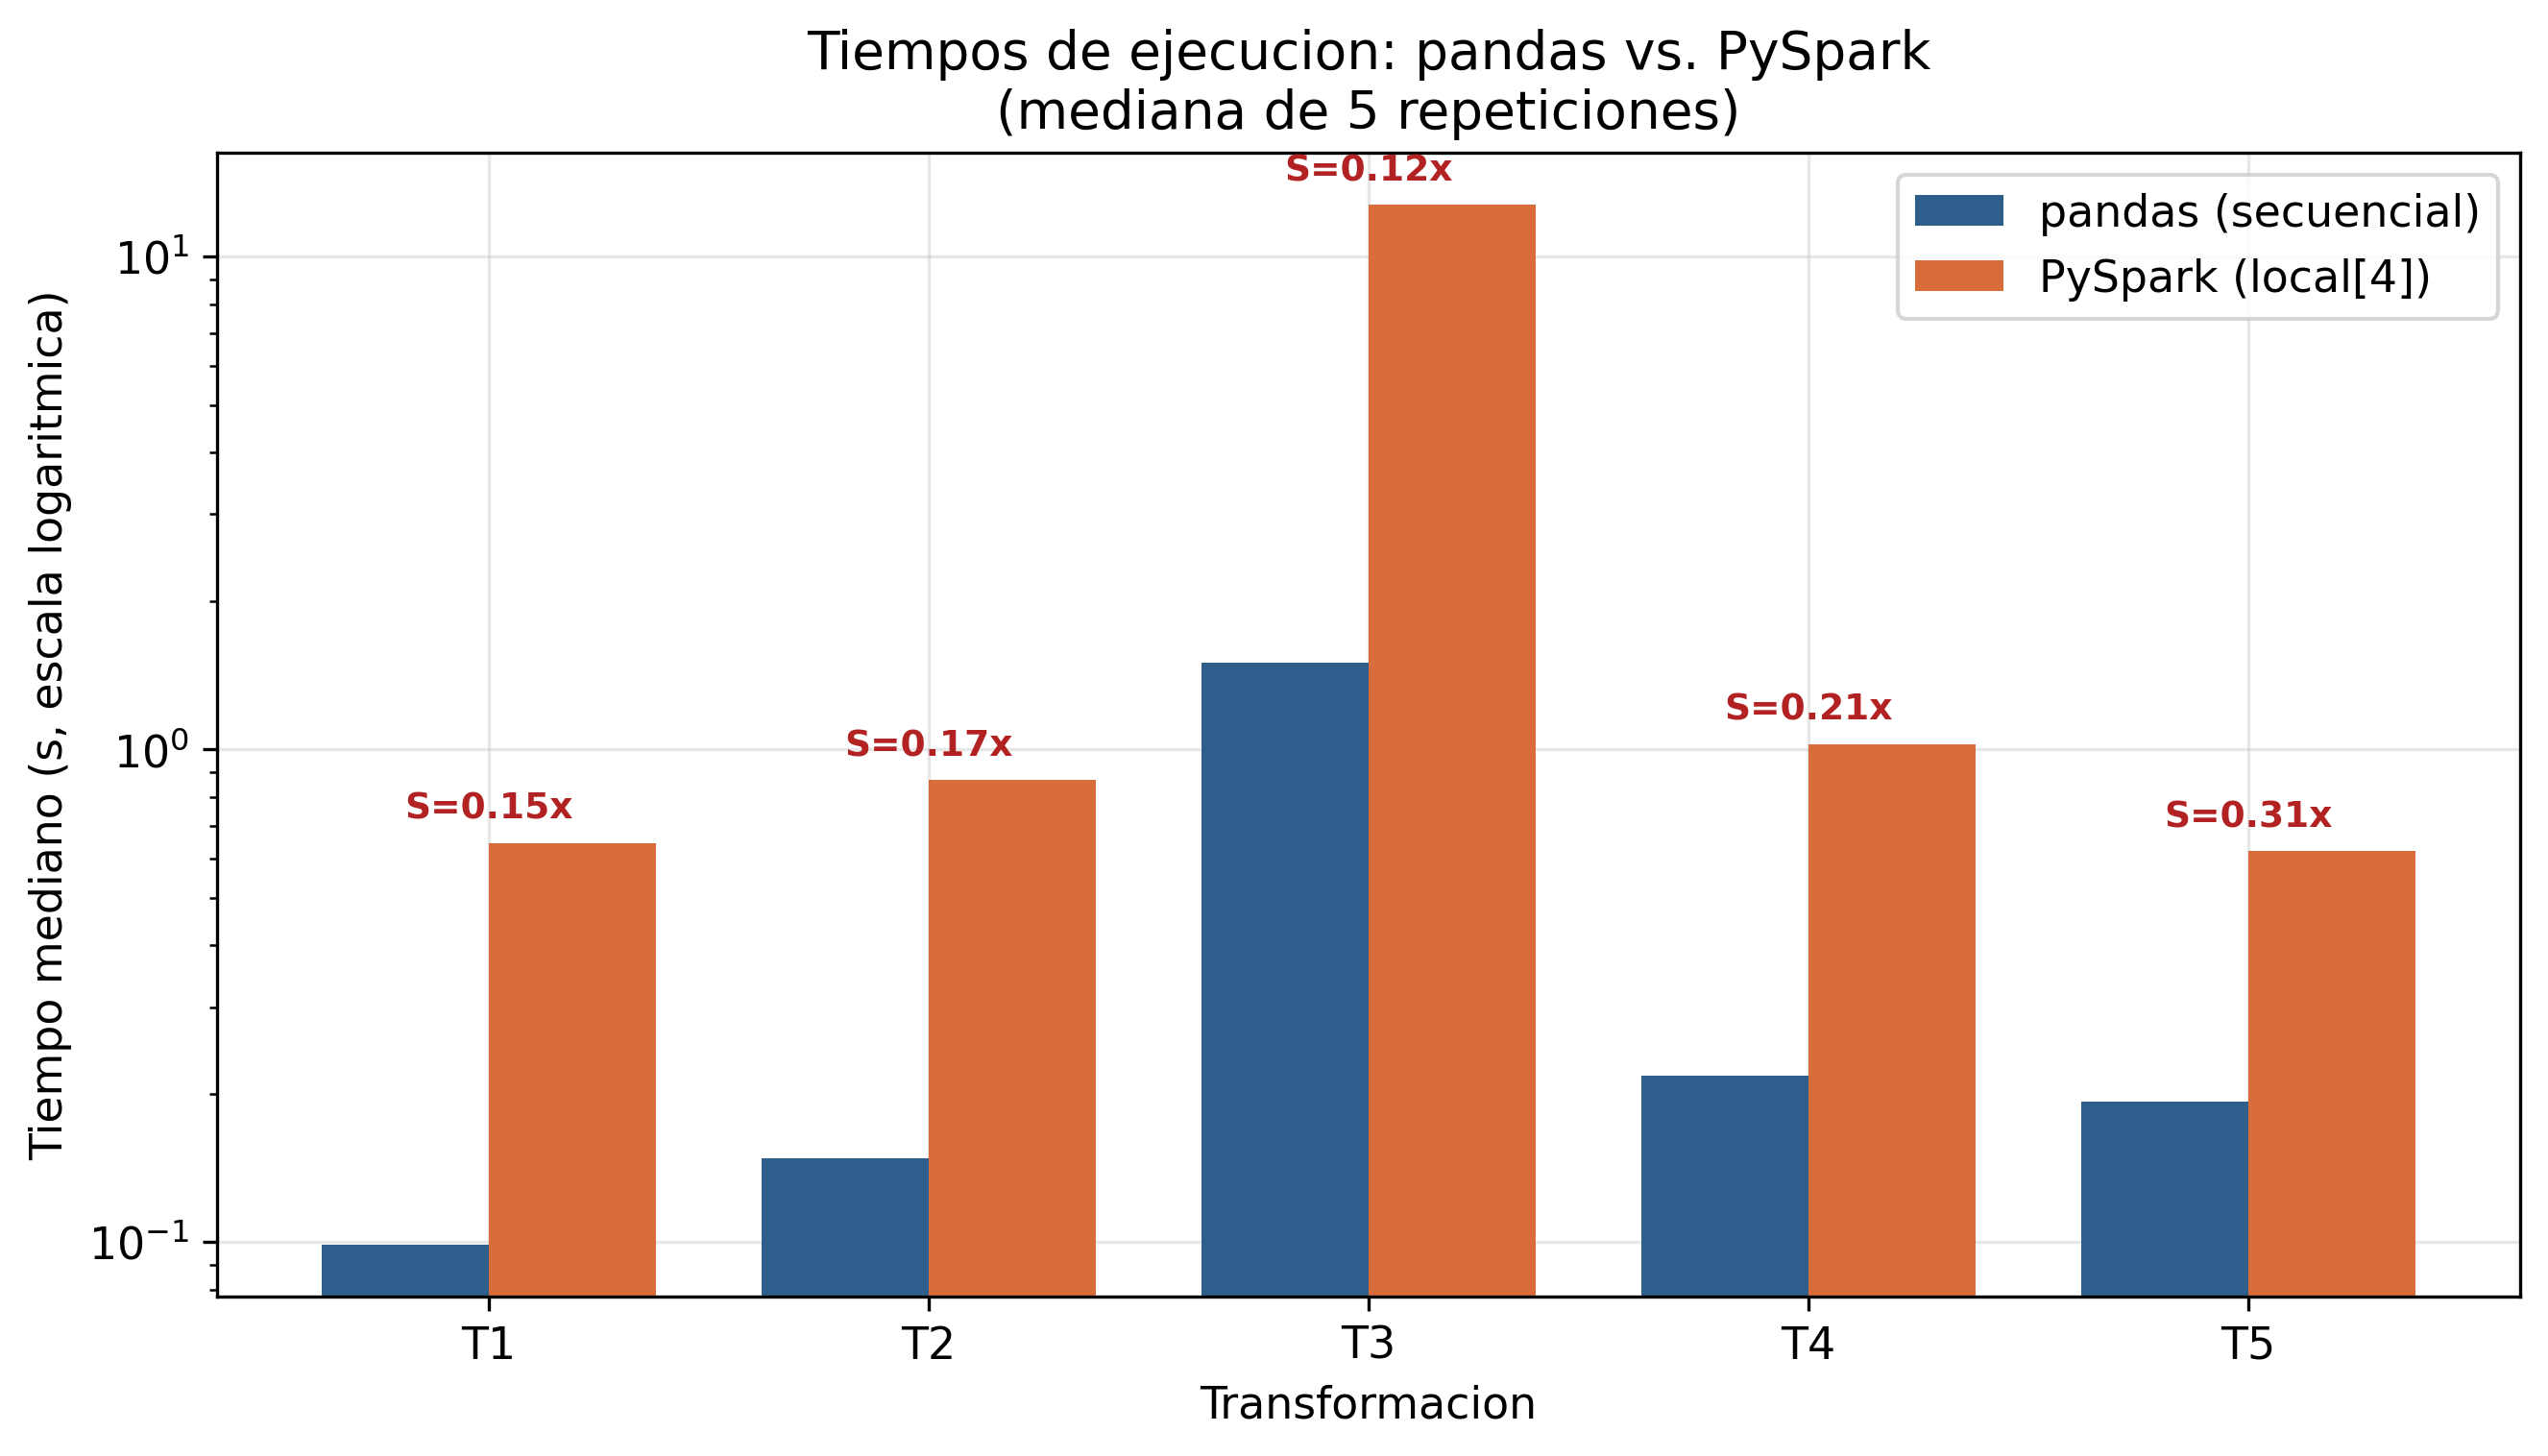

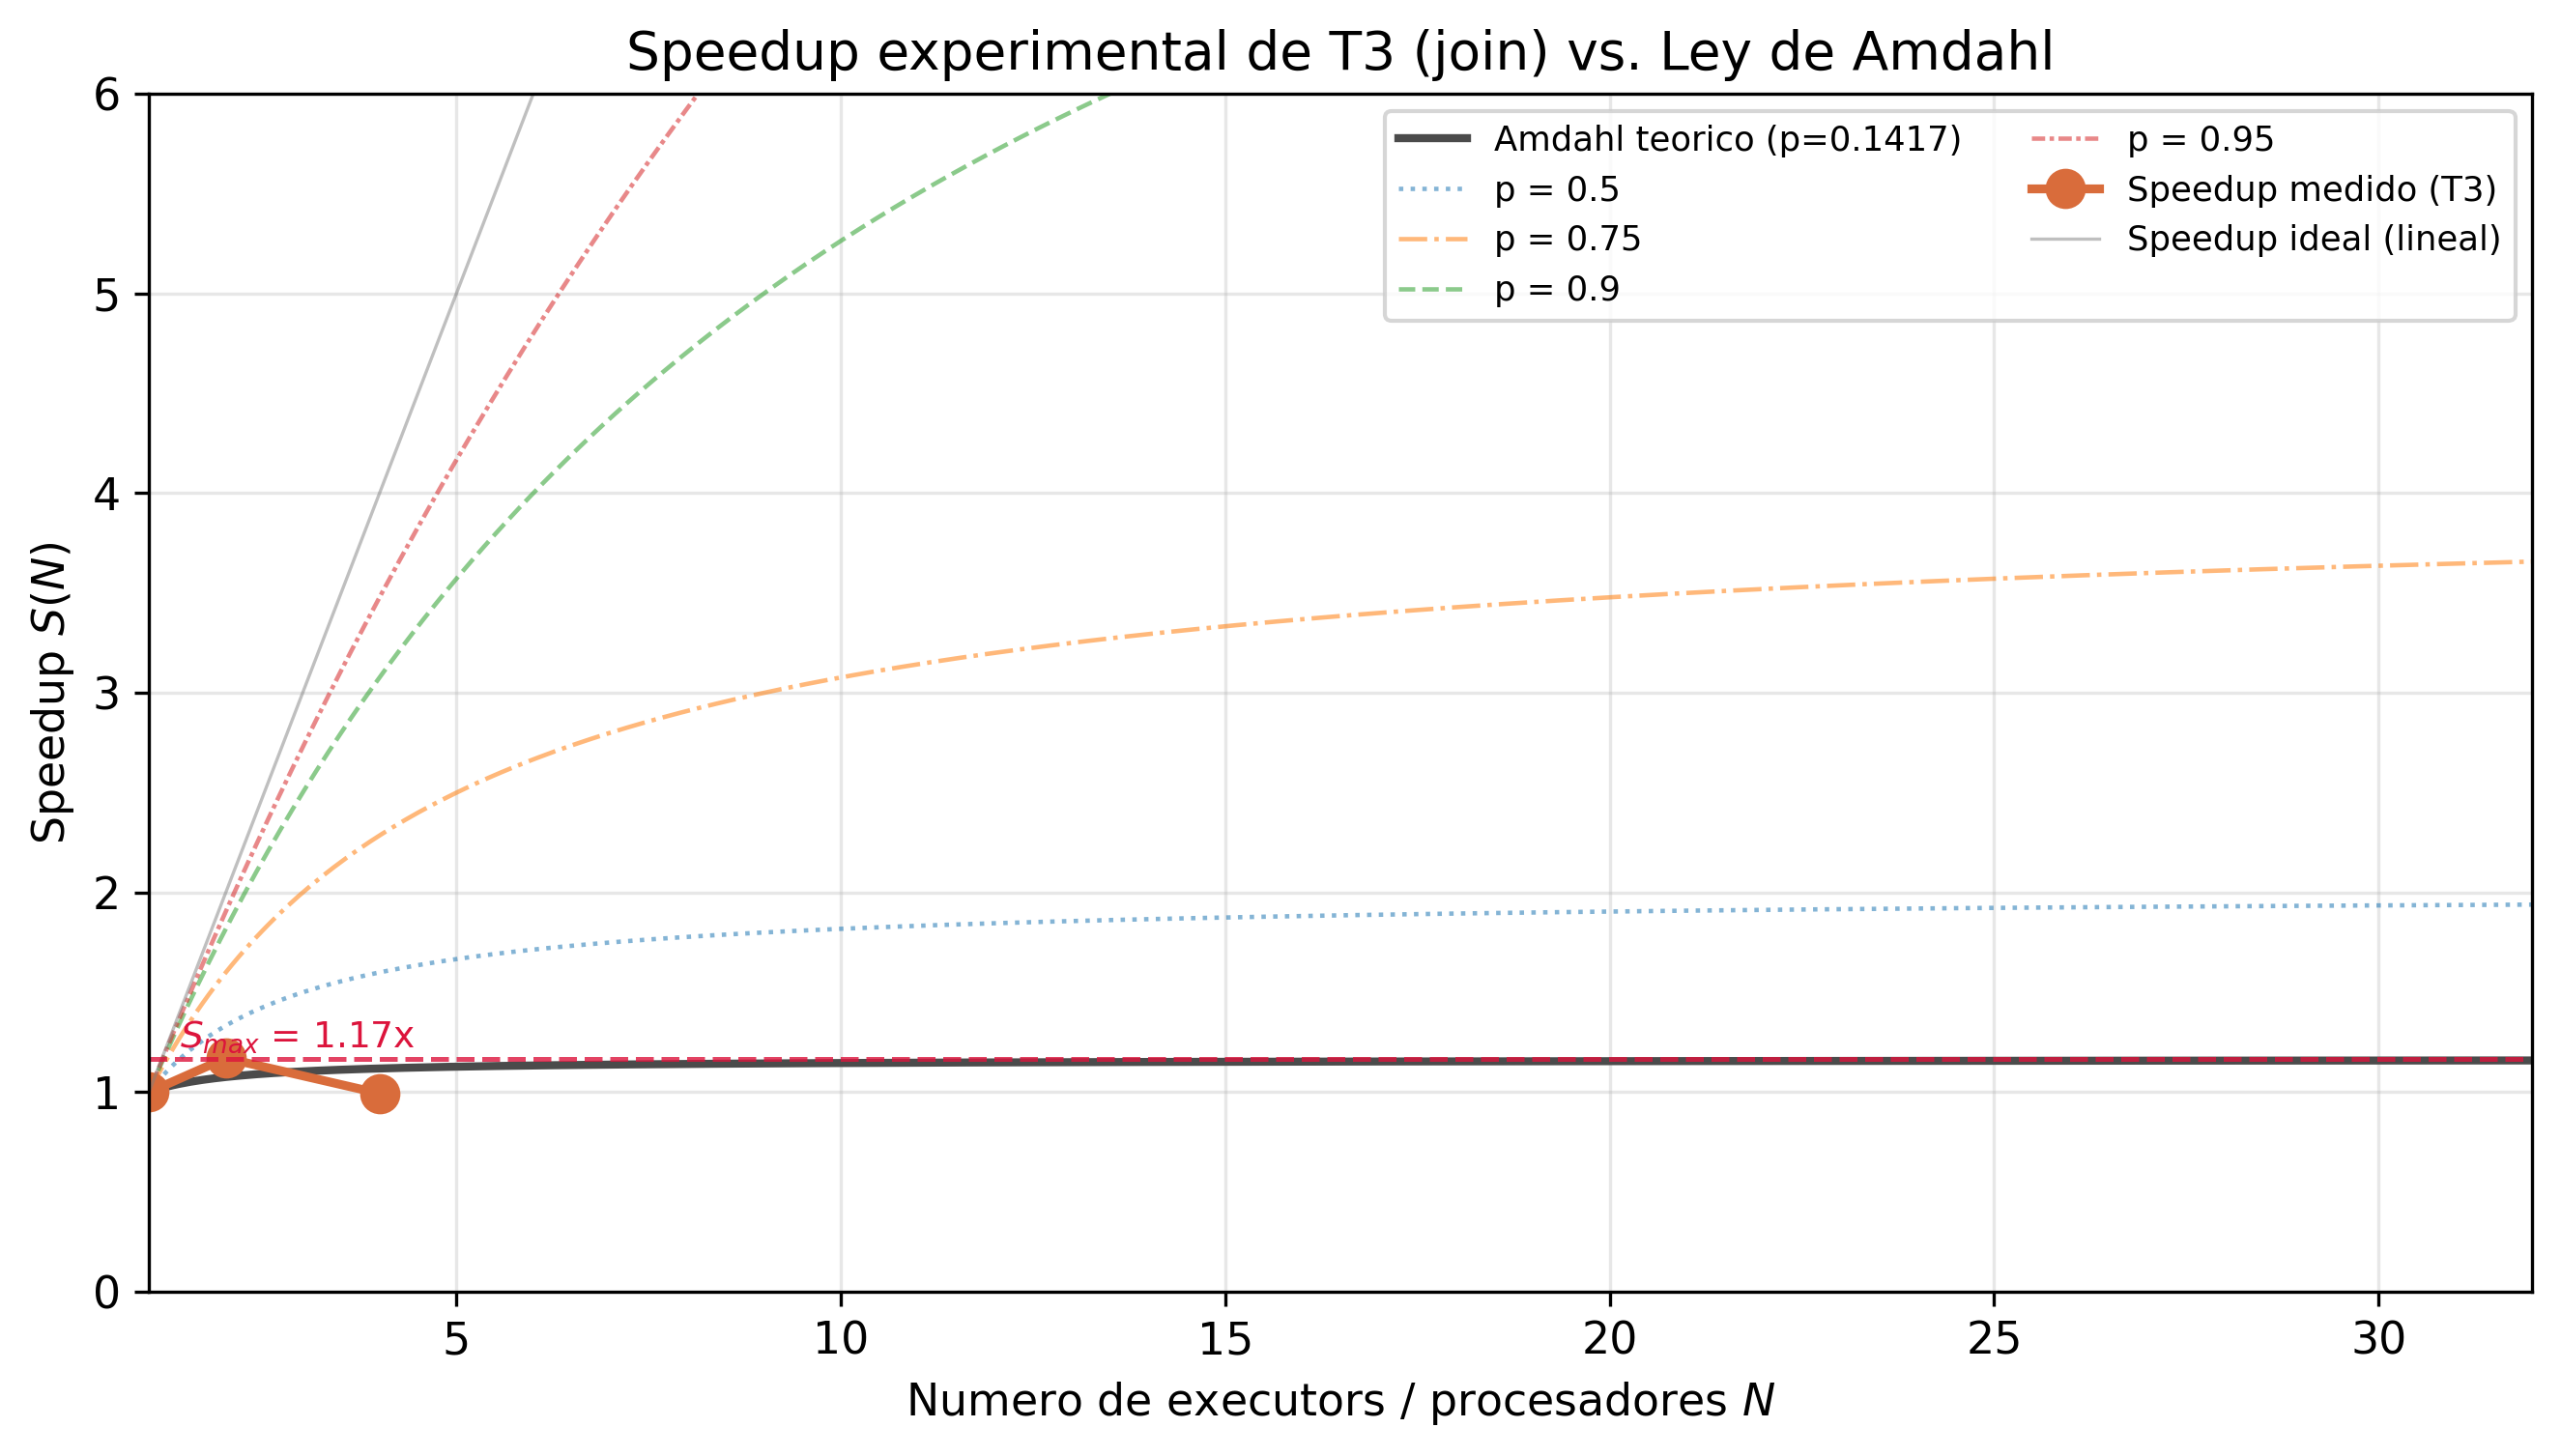

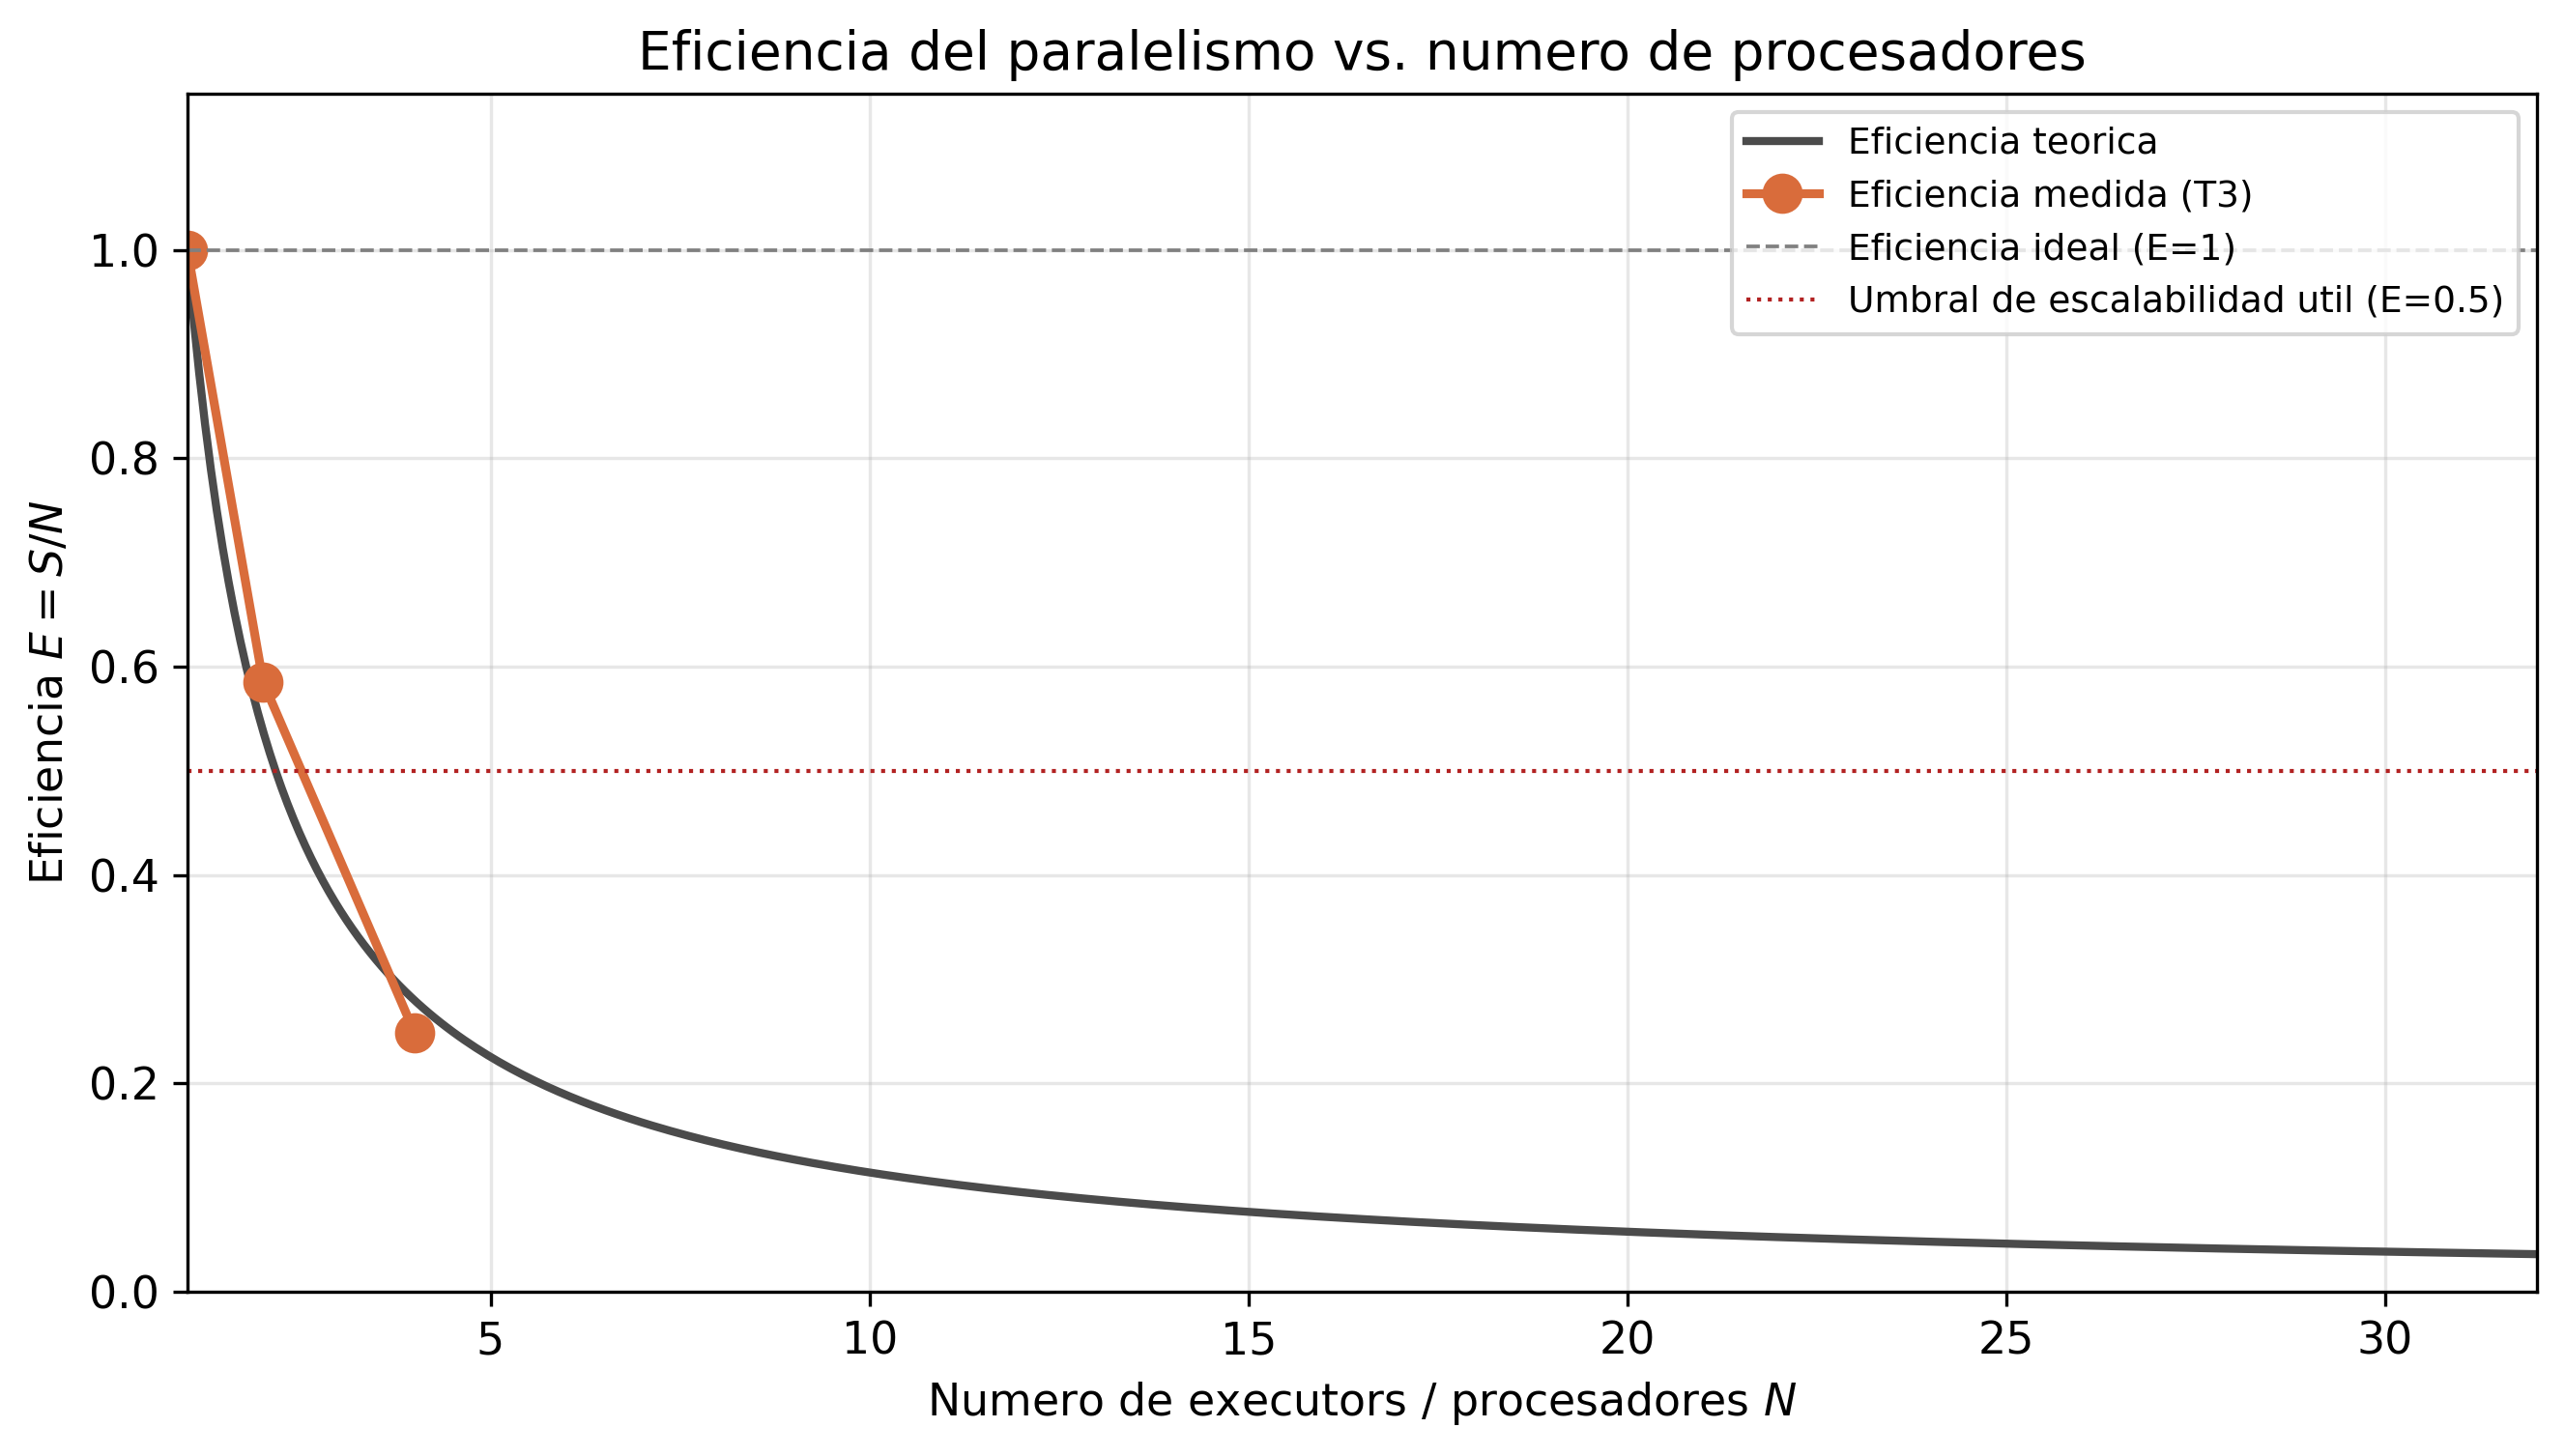

In [ ]:
import json
from IPython.display import Image, display

ruta_json = os.path.join(RAIZ, "salida_pe_u4", "resultados.json")
with open(ruta_json) as f:
    res = json.load(f)

print("=" * 60)
print("ANALISIS DE AMDAHL")
print("=" * 60)
a = res["amdahl"]
print("Fraccion paralelizable p   : {:.4f}".format(a["p_paralelizable"]))
print("Fraccion serial (1-p)      : {:.4f}".format(a["fraccion_serial"]))
print("Speedup teorico maximo     : {:.3f}x".format(a["S_max"]))
print("Procesadores para el 90%   :", int(a["N_90_entero"]))
print()
print("=" * 60)
print("VERIFICACION pandas vs PySpark")
print("=" * 60)
for tx, v in res["verificacion"].items():
    estado = "IDENTICO" if v["identico"] else "REVISAR"
    print("  {}: {}  ({:,} filas)".format(tx, estado, v["filas_pandas"]))

for fig in ["fig_a_tiempos.png", "fig_b_speedup_amdahl.png", "fig_c_eficiencia.png"]:
    print()
    display(Image(os.path.join(RAIZ, "salida_pe_u4", "figs", fig)))

## Celda 7 — Exportación de resultados

Genera un ZIP con los CSV, las figuras a 300 DPI, las tablas LaTeX y el JSON.

In [ ]:
import shutil
from google.colab import files

ruta_zip = shutil.make_archive(
    "/content/PE_U4_resultados", "zip", os.path.join(RAIZ, "salida_pe_u4")
)
print("ZIP generado: {:.1f} MB".format(os.path.getsize(ruta_zip) / 1e6))
files.download(ruta_zip)

ZIP generado: 335.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Celda 8 — Captura para la carpeta `evidencia/`

Documenta la máquina, las versiones de las librerías y los parámetros del
experimento. La salida de esta celda se conserva en `evidencia/` como
constancia de que la ejecución se realizó en Google Colab, conforme al
entorno establecido en la guía de práctica.

In [ ]:
import platform, multiprocessing, pyspark, pandas as pd, numpy as np
from datetime import datetime

print("=" * 62)
print("  EVIDENCIA DE EJECUCION - PE-U4")
print("=" * 62)
print("  Fecha y hora    :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("  Entorno         : Google Colab")
print("  Sistema         :", platform.platform())
print("  Python          :", platform.python_version())
print("  Nucleos de CPU  :", multiprocessing.cpu_count())
print("  PySpark         :", pyspark.__version__)
print("  pandas          :", pd.__version__)
print("  NumPy           :", np.__version__)
print("-" * 62)
print("  Registros       : {:,}".format(res["configuracion"]["n_reservas"]))
print("  Semilla         :", res["configuracion"]["semilla"])
print("  Repeticiones    :", res["configuracion"]["repeticiones"])
print("=" * 62)
!free -h

  EVIDENCIA DE EJECUCION - PE-U4
  Fecha y hora    : 2026-08-09 01:16:49
  Entorno         : Google Colab
  Sistema         : Linux-6.6.122+-x86_64-with-glibc2.35
  Python          : 3.12.13
  Nucleos de CPU  : 2
  PySpark         : 3.5.0
  pandas          : 2.2.2
  NumPy           : 2.0.2
--------------------------------------------------------------
  Registros       : 520,000
  Semilla         : 20260808
  Repeticiones    : 5
               total        used        free      shared  buff/cache   available
Mem:            12Gi       4.8Gi       164Mi       2.0Mi       7.7Gi       7.6Gi
Swap:             0B          0B          0B
